# Modular Time-Series Notebook Toolkit – Full Demo

**`aic_ts_suite`** — Interactive R&D extension bridging raw data ingestion and advanced predictive modelling.

This notebook walks through every module of the toolkit:

| # | Section | Module |
|---|---------|--------|
| 1 | Configuration & Traceability | `config` |
| 2 | Data Ingestion & Connectivity | `connectivity` |
| 3 | Data Cleaning & Sanitisation | `cleaning` |
| 4 | Variance-Stabilising Transforms | `signals.transforms` |
| 5 | EDA Visualisation | `viz` |
| 6 | Feature Engineering (Fourier, MAs, Lags) | `features` |
| 7 | Univariate Forecasting | `forecasting.univariate` |
| 7b | XGBoost Forecasting | `forecasting.ml_models` |
| 7c | Prophet Forecasting | `forecasting.ml_models` |
| 8 | Multivariate Forecasting (VAR) | `forecasting.multivariate` |
| 9 | Neural & Foundation Models | `forecasting.neural` |
| 10 | KPI Evaluation & Comparison | `evaluation` |
| 11 | Styled Display & Metric Cards | `display` |

---
## 0 — Setup & Imports

In [42]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Ensure the toolkit package is importable
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('Environment ready.')

Environment ready.


---
## 1 — Configuration & Traceability

Every notebook-initiated run propagates a **correlationId** (UUID v4) for end-to-end traceability.

In [43]:
from aic_ts_suite.config import CONFIG

print(f"Correlation ID : {CONFIG.correlation_id}")
print(f"TimescaleDB DSN: {CONFIG.timescale.dsn}")
print(f"Confidence     : {CONFIG.confidence_level*100:.0f} %")
print(f"Sanitise strat : {CONFIG.default_sanitize_strategy}")

Correlation ID : 5f9470a5-bbc3-4705-b343-c77684442cb2
TimescaleDB DSN: postgresql://readonly:@10.20.0.10:5432/tsdb
Confidence     : 95 %
Sanitise strat : interpolate


---
## 2 — Data Ingestion (Synthetic Demo Data)

We generate a synthetic monthly time-series with trend, seasonality, and random noise.  
In production this would be replaced by `TimescaleClient.fetch_sensor()` or `read_csv()` / `read_excel()`.

In [44]:
from aic_ts_suite.connectivity.models import TimeSeriesObservation

# ── Synthetic data: 10 years of monthly observations ──
np.random.seed(CONFIG.random_state)
n = 120  # 10 years
dates = pd.date_range('2016-01-01', periods=n, freq='MS')
trend = np.linspace(50, 90, n)
seasonal = 10 * np.sin(2 * np.pi * np.arange(n) / 12)
noise = np.random.normal(0, 2, n)
values = trend + seasonal + noise

# Inject 5 % missing values
mask = np.random.rand(n) < 0.05
values[mask] = np.nan

raw_df = pd.DataFrame({'timestamp': dates, 'temperature': values})
print(f"Raw shape: {raw_df.shape}  |  NaN count: {raw_df['temperature'].isna().sum()}")
raw_df.head(10)

Raw shape: (120, 2)  |  NaN count: 6


,timestamp,temperature
0,2016-01-01,50.993428
1,2016-02-01,55.059606
2,2016-03-01,60.627900
3,2016-04-01,64.054463
4,2016-05-01,59.536485
5,2016-06-01,56.212398
6,2016-07-01,55.175232
7,2016-08-01,48.887811
8,2016-09-01,43.089873
9,2016-10-01,44.110330


### 2.1 — TimeSeriesObservation model

In [45]:
# Convert the first row into the platform-standard observation envelope
obs = TimeSeriesObservation.from_datetime(
    timestamp=dates[0], value=float(values[0] if not np.isnan(values[0]) else 0), series_id='sensor_42'
)
print(obs)
print(f"  → epoch ms : {obs.timestamp_ms}")
print(f"  → UTC dt   : {obs.datetime_utc}")

TimeSeriesObservation(timestamp_ms=1451606400000, value=50.993428306022466, series_id='sensor_42')
  → epoch ms : 1451606400000
  → UTC dt   : 2016-01-01 00:00:00+00:00


---
## 3 — Data Cleaning & Sanitisation

In [46]:
from aic_ts_suite.cleaning import sanitize

# Strategy 1: linear interpolation (default)
clean_df = sanitize(raw_df, strategy='interpolate')

print(f"NaN after interpolate: {clean_df['temperature'].isna().sum()}")
clean_df.head()

NaN after interpolate: 0


,timestamp,temperature
0,2016-01-01,50.993428
1,2016-02-01,55.059606
2,2016-03-01,60.627900
3,2016-04-01,64.054463
4,2016-05-01,59.536485


In [47]:
# Strategy 2: forward-fill
ffill_df = sanitize(raw_df, strategy='ffill')
print(f"NaN after ffill: {ffill_df['temperature'].isna().sum()}")

NaN after ffill: 0


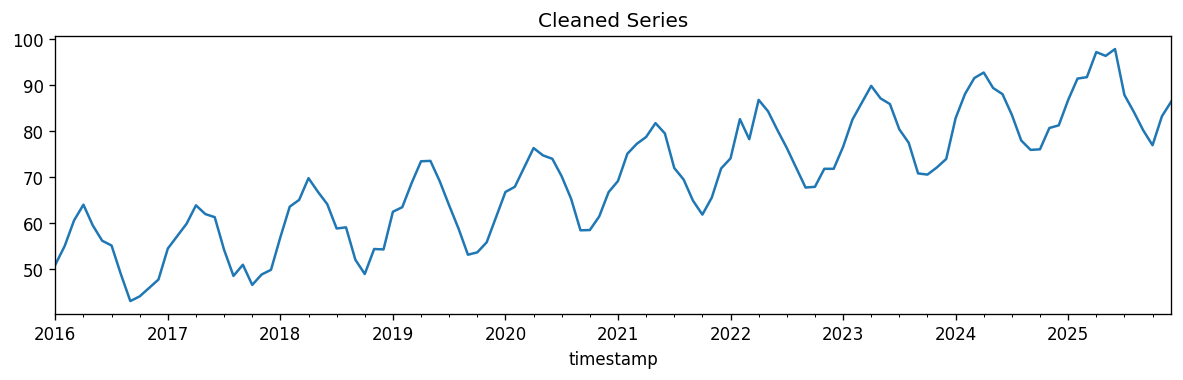

In [48]:
# ── Prepare a datetime-indexed Series for downstream modules ──
ts = clean_df.set_index('timestamp')['temperature']
ts.name = 'Temperature'
ts.plot(figsize=(12, 3), title='Cleaned Series');

### 3.1 — Timestamp Normalisation to Epoch Milliseconds

In [49]:
from aic_ts_suite.cleaning import DataCleaner

# Save a temp CSV to demonstrate the full DataCleaner pipeline
raw_df.to_csv('/tmp/demo_sensor.csv', index=False)

pipeline_df = (
    DataCleaner('/tmp/demo_sensor.csv', timestamp_col='timestamp')
    .load()
    .sanitize('interpolate')
    .to_epoch_ms()
    .result()
)
pipeline_df[['timestamp', 'temperature', 'timestamp_ms']].head()

,timestamp,temperature,timestamp_ms
0,2016-01-01,50.993428,1451606400000
1,2016-02-01,55.059606,1454284800000
2,2016-03-01,60.627900,1456790400000
3,2016-04-01,64.054463,1459468800000
4,2016-05-01,59.536485,1462060800000


---
## 4 — Variance-Stabilising Transforms

Box-Cox λ (MLE) = 0.7964


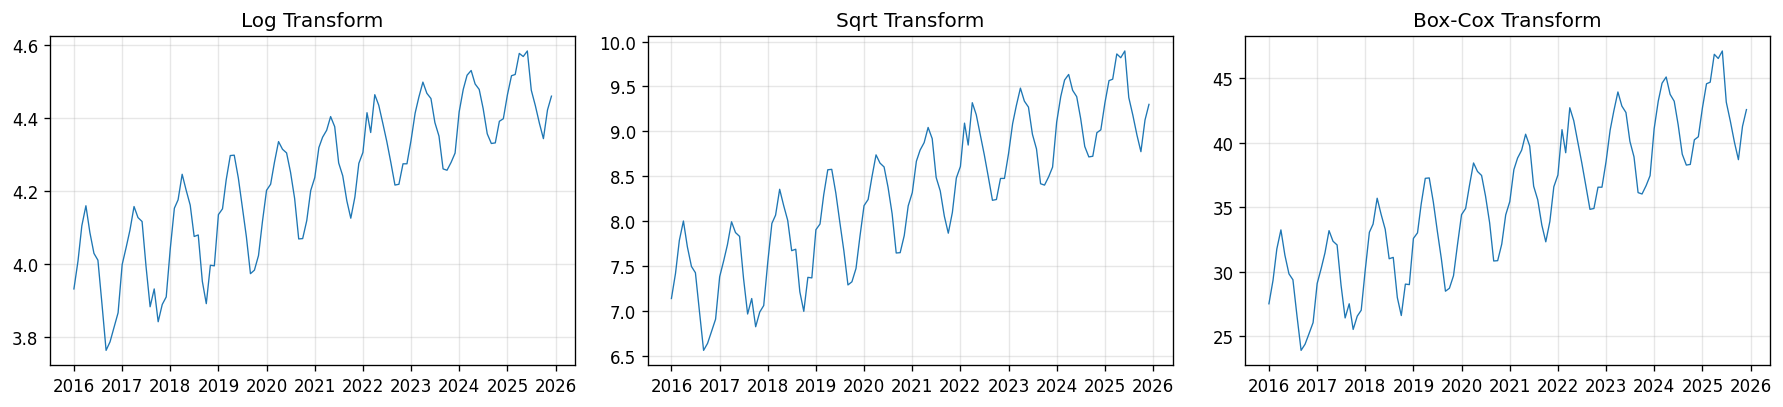

In [50]:
from aic_ts_suite.signals.transforms import LogTransform, SqrtTransform, BoxCoxTransform

log_t  = LogTransform()
sqrt_t = SqrtTransform()
bc_t   = BoxCoxTransform()

ts_log  = log_t.apply(ts)
ts_sqrt = sqrt_t.apply(ts)
ts_bc   = bc_t.apply(ts)

print(f"Box-Cox λ (MLE) = {bc_t.lmbda:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, transformed, label in zip(axes, [ts_log, ts_sqrt, ts_bc], ['Log', 'Sqrt', 'Box-Cox']):
    ax.plot(transformed, linewidth=0.8)
    ax.set_title(f'{label} Transform')
    ax.grid(True, alpha=0.3)
fig.tight_layout()

In [51]:
# Verify round-trip (inverse recovers original)
ts_recovered = bc_t.inverse(ts_bc)
roundtrip_error = (ts - ts_recovered).abs().max()
print(f"Box-Cox round-trip max error: {roundtrip_error:.2e}")

Box-Cox round-trip max error: 4.26e-14


---
## 5 — Exploratory Data Analysis (EDA) Visualisation

### 5.1 — Seasonal Plot

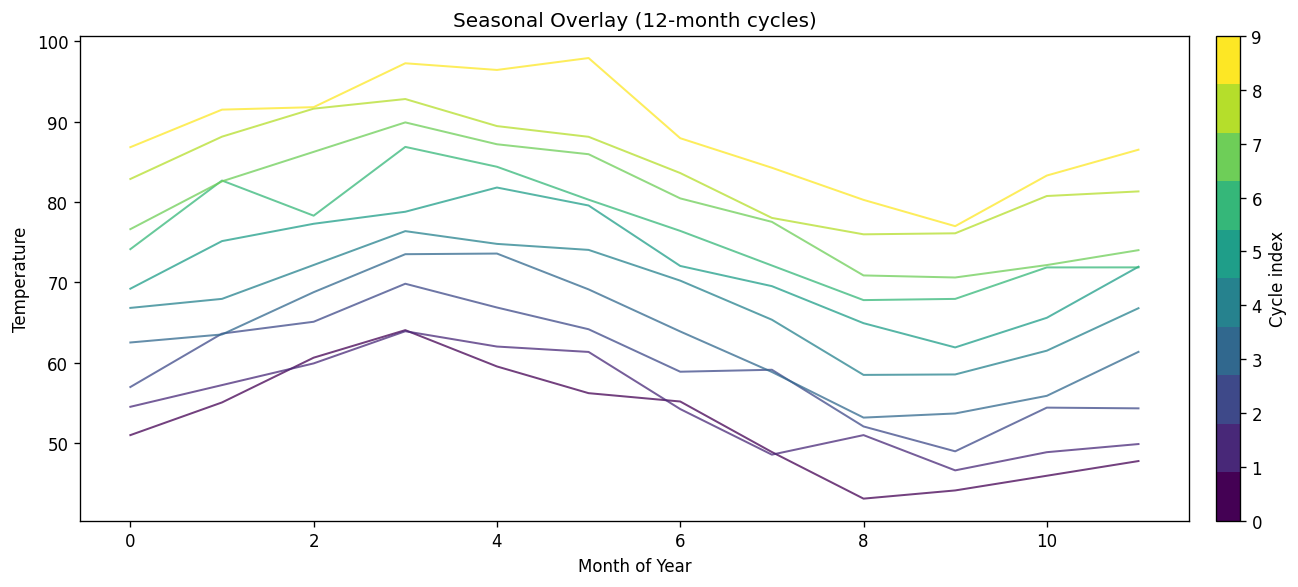

In [52]:
from aic_ts_suite.viz import plot_seasonal

plot_seasonal(ts, period=12, freq_label='Month of Year', title='Seasonal Overlay (12-month cycles)');

### 5.2 — ACF / PACF

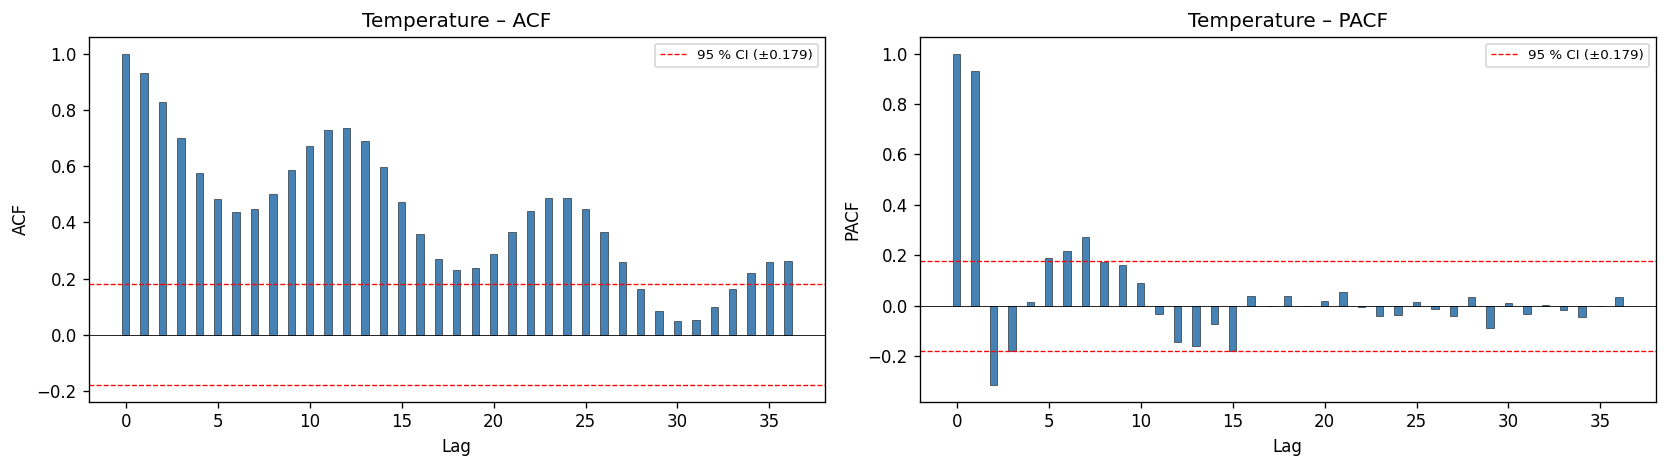

In [53]:
from aic_ts_suite.viz import plot_acf_pacf

plot_acf_pacf(ts, lags=36, title_prefix='Temperature – ');

### 5.3 — Classical Decomposition  (Y = T + S + R)

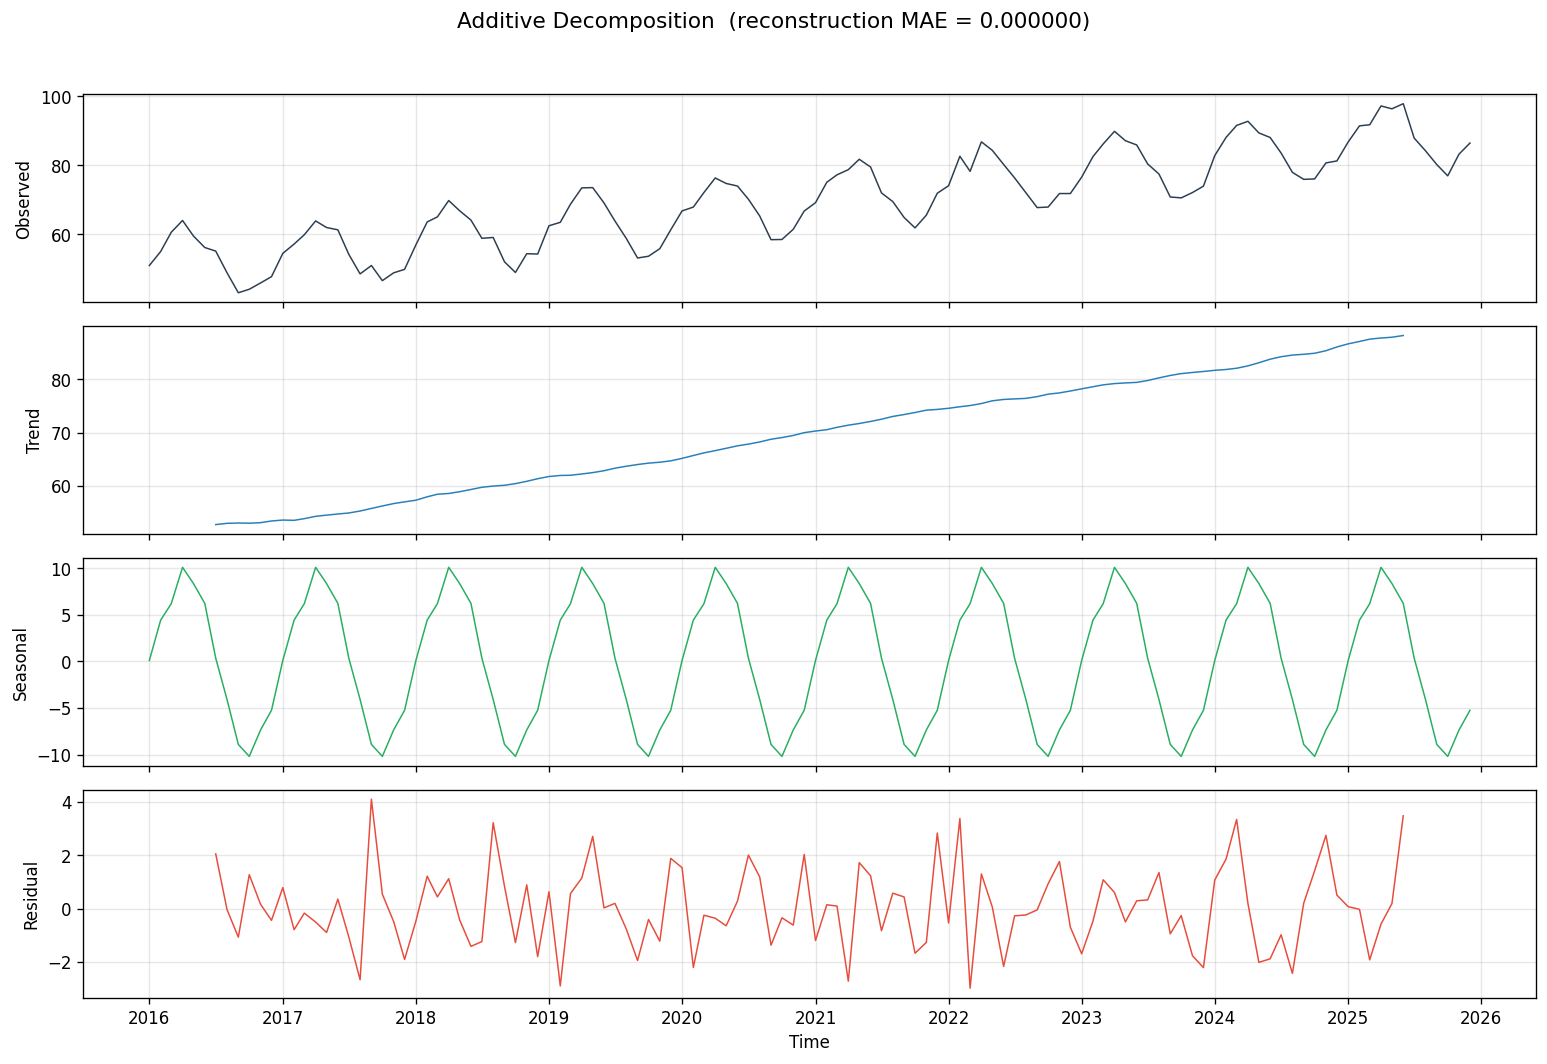

In [54]:
from aic_ts_suite.viz import plot_decomposition

plot_decomposition(ts, period=12, model='additive', title='Additive Decomposition');

---
## 6 — Feature Engineering for XGBoost

### 6.1 — Fourier Harmonic Terms

In [55]:
from aic_ts_suite.features import fourier_terms, optimal_k

# Use the weekly-annual period (52.18 weeks / year) as an example
K_star = optimal_k(ts, period=12, max_K=6)
print(f"Optimal K for period=12: {K_star}")

ft = fourier_terms(n=len(ts), period=12, K=K_star)
ft.index = ts.index
ft.head()

Optimal K for period=12: 1


,sin_1,cos_1
timestamp,,
2016-01-01,0.500000,8.660254e-01
2016-02-01,0.866025,5.000000e-01
2016-03-01,1.000000,6.123234e-17
2016-04-01,0.866025,-5.000000e-01
2016-05-01,0.500000,-8.660254e-01


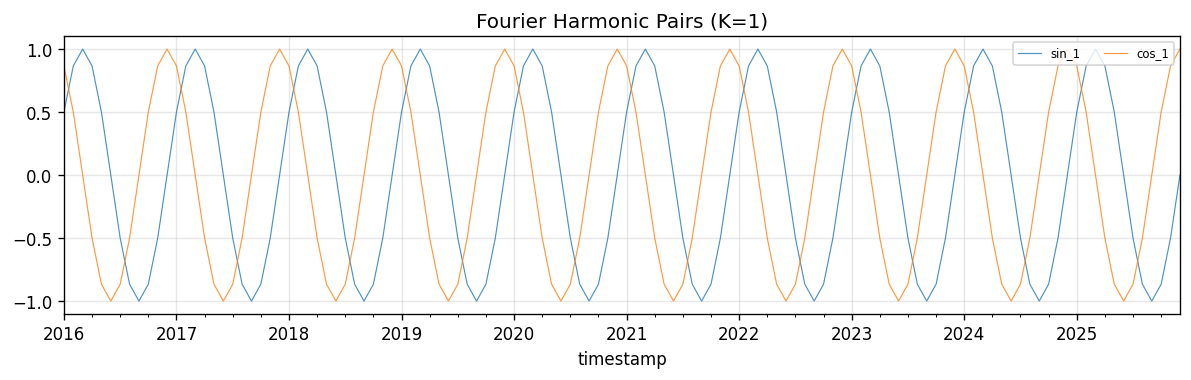

In [56]:
fig, ax = plt.subplots(figsize=(12, 3))
ft.plot(ax=ax, linewidth=0.7, alpha=0.8)
ax.set_title(f'Fourier Harmonic Pairs (K={K_star})')
ax.legend(ncol=K_star*2, fontsize=7)
ax.grid(True, alpha=0.3);

### 6.2 — Moving Averages

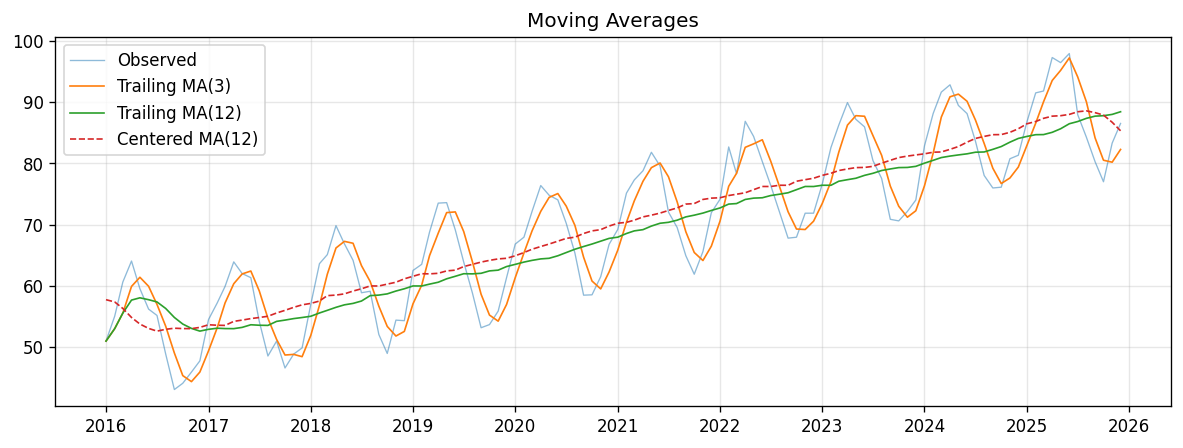

In [57]:
from aic_ts_suite.features import trailing_moving_average, centered_moving_average

trail_3 = trailing_moving_average(ts, window=3)
trail_12 = trailing_moving_average(ts, window=12)
center_12 = centered_moving_average(ts, window=12)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts, label='Observed', alpha=0.5, linewidth=0.8)
ax.plot(trail_3, label='Trailing MA(3)', linewidth=1)
ax.plot(trail_12, label='Trailing MA(12)', linewidth=1)
ax.plot(center_12, label='Centered MA(12)', linewidth=1, linestyle='--')
ax.legend()
ax.set_title('Moving Averages')
ax.grid(True, alpha=0.3);

### 6.3 — Lag Features for Supervised ML

Build a supervised regression matrix from the univariate series using lag columns, rolling statistics, and Fourier terms. This matrix is consumed by `XGBoostForecaster` automatically, but you can also build it manually.

In [ ]:
from aic_ts_suite.features import lag_features, rolling_lag_features, build_supervised_matrix

# Individual lag columns
lags_df = lag_features(ts, lags=6)
print("Lag features shape:", lags_df.shape)
display(lags_df.head(8))

# Rolling statistics (mean & std over multiple windows)
roll_df = rolling_lag_features(ts, windows=[3, 6, 12])
print("\nRolling features shape:", roll_df.shape)
display(roll_df.head(8))

# Full supervised matrix (lags + rolling + Fourier) — ready for XGBoost
sup = build_supervised_matrix(ts, lags=12, rolling_windows=[3, 6, 12], fourier_k=4, seasonal_period=12)
print(f"\nSupervised matrix: {sup.shape[0]} rows × {sup.shape[1]} columns")
print("Columns:", list(sup.columns))
display(sup.tail(5))

TypeError: 'int' object is not iterable

---
## 7 — Univariate Forecasting

We split the series into **train** (first 108 months) and **test** (last 12 months), then compare AutoARIMA, AutoETS, and Holt-Winters.

In [ ]:
HORIZON = 12
train, test = ts.iloc[:-HORIZON], ts.iloc[-HORIZON:]
print(f"Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} obs)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()}    ({len(test)} obs)")

In [ ]:
from aic_ts_suite.forecasting import (
    AutoARIMAForecaster,
    AutoETSForecaster,
    HoltWintersForecaster,
)

# ── AutoARIMA ──
arima = AutoARIMAForecaster(seasonal=True, m=12)
res_arima = arima.fit_predict(train, HORIZON, start=test.index[0], freq='MS')
res_arima.forecast.index = test.index
if res_arima.lower is not None:
    res_arima.lower.index = test.index
    res_arima.upper.index = test.index
print(f"AutoARIMA  AICc={res_arima.info_criteria['AICc']:.2f}  ({res_arima.duration_ms:.0f} ms)")

In [ ]:
# ── AutoETS ──
ets = AutoETSForecaster(seasonal_periods=12)
res_ets = ets.fit_predict(train, HORIZON)
res_ets.forecast.index = test.index
print(f"AutoETS    AICc={res_ets.info_criteria.get('AICc', float('nan')):.2f}  ({res_ets.duration_ms:.0f} ms)")

In [ ]:
# ── Holt-Winters ──
hw = HoltWintersForecaster(seasonal='add', seasonal_periods=12)
res_hw = hw.fit_predict(train, HORIZON)
res_hw.forecast.index = test.index
print(f"Holt-Wint  AICc={res_hw.info_criteria.get('AICc', float('nan')):.2f}  ({res_hw.duration_ms:.0f} ms)")

### 7.1 — Automated Selection via AICc Minimisation

In [ ]:
from aic_ts_suite.forecasting import auto_select_univariate

best = auto_select_univariate(train, HORIZON, seasonal_periods=12, start=test.index[0], freq='MS')
best.forecast.index = test.index
if best.lower is not None:
    best.lower.index = test.index
    best.upper.index = test.index
print(f"Best model: {best.model_name}  AICc={best.info_criteria.get('AICc', float('nan')):.2f}")

### 7.2 — XGBoost Forecasting (ML-based)

`XGBoostForecaster` automatically builds a supervised matrix of lag features, rolling statistics, and Fourier terms, then fits three gradient-boosted trees (point forecast + quantile regressions for prediction intervals). Multi-step forecasts are generated recursively.

In [ ]:
from aic_ts_suite.forecasting import XGBoostForecaster

xgb_fc = XGBoostForecaster(
    lags=12,
    rolling_windows=[3, 6, 12],
    fourier_k=4,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
)
res_xgb = xgb_fc.fit_predict(train, HORIZON)
res_xgb.forecast.index = test.index
if res_xgb.lower is not None:
    res_xgb.lower.index = test.index
    res_xgb.upper.index = test.index

print(f"XGBoost  RMSE (quick check): {((test - res_xgb.forecast)**2).mean()**0.5:.3f}")
print(f"         Duration: {res_xgb.duration_ms:.0f} ms")

### 7.3 — Prophet Forecasting

Facebook Prophet decomposes the series into trend + seasonality + holidays using a Bayesian structural model. Native uncertainty intervals are included.

In [ ]:
from aic_ts_suite.forecasting import ProphetForecaster

prophet_fc = ProphetForecaster(
    growth='linear',
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
)
res_prophet = prophet_fc.fit_predict(train, HORIZON)
res_prophet.forecast.index = test.index
if res_prophet.lower is not None:
    res_prophet.lower.index = test.index
    res_prophet.upper.index = test.index

print(f"Prophet  RMSE (quick check): {((test - res_prophet.forecast)**2).mean()**0.5:.3f}")
print(f"         Duration: {res_prophet.duration_ms:.0f} ms")

---
## 8 — Multivariate Forecasting (VAR)

In [ ]:
from aic_ts_suite.forecasting import VARForecaster

# Create a second correlated series for the VAR demo
np.random.seed(42)
humidity = 0.6 * ts + 15 + np.random.normal(0, 3, len(ts))
humidity.name = 'Humidity'

multi_df = pd.DataFrame({'Temperature': ts, 'Humidity': humidity})
multi_train = multi_df.iloc[:-HORIZON]
multi_test  = multi_df.iloc[-HORIZON:]

var = VARForecaster(maxlags=12, ic='aic')
res_var = var.fit_predict(multi_train, HORIZON)
res_var.forecast.index = test.index

print(f"VAR lag order: {res_var.extra['lag_order']}")
print(f"VAR AIC={res_var.info_criteria['AIC']:.2f}  BIC={res_var.info_criteria['BIC']:.2f}")
print(f"\nGranger Causality (significant at α=0.05):")
for pair, info in res_var.extra['granger'].items():
    if info['min_p_value'] < 0.05:
        print(f"  {pair} (p={info['min_p_value']:.4f})")

---
## 9 — Train / Test Forecast Visualisation

In [ ]:
from aic_ts_suite.viz import plot_forecast
from aic_ts_suite.evaluation import compute_all_kpis

kpis_arima = compute_all_kpis(test, res_arima.forecast)

plot_forecast(
    observed=ts,
    forecast=res_arima.forecast,
    lower=res_arima.lower,
    upper=res_arima.upper,
    train_end=train.index[-1],
    kpis=kpis_arima,
    title='AutoARIMA – Observed vs Forecast',
);

---
## 10 — KPI Evaluation & Model Comparison Leaderboard

In [ ]:
from aic_ts_suite.evaluation import ModelComparison

cmp = ModelComparison(observed_test=test)
cmp.add(res_arima)
cmp.add(res_ets)
cmp.add(res_hw)
cmp.add(res_xgb)
cmp.add(res_prophet)
cmp.add(res_var)         # VAR forecast (Temperature column)


leaderboard = cmp.leaderboard(sort_by='RMSE')leaderboard

In [ ]:
# ── Metric delta tracking (improvement vs. baseline) ──
deltas = cmp.metric_deltas(baseline_model=leaderboard.iloc[0]['Model'])
deltas

In [ ]:
# ── Per-model forecast overlay plots with KPI annotation boxes ──
figs = cmp.plot_all(observed_full=ts, train_end=train.index[-1])

---
## 11 — Styled Display & Metric Cards

In [ ]:
from aic_ts_suite.display import styled_summary, metric_cards

# Professional HTML statistical summary
_ = styled_summary(
    ts.describe().to_frame(),
    caption='Temperature – Descriptive Statistics',
)

In [ ]:
# Metric cards for best model
best_kpis = compute_all_kpis(test, res_arima.forecast)
best_kpis['Duration (ms)'] = res_arima.duration_ms
best_kpis['correlationId'] = CONFIG.correlation_id[:8] + '…'

_ = metric_cards(best_kpis)

---
## 12 — AnalyticsEngineClient — Run Traceability

In [ ]:
from aic_ts_suite.evaluation import AnalyticsEngineClient

client = AnalyticsEngineClient()
client.log_run(res_arima, test)
client.log_run(res_ets, test)
client.log_run(res_hw, test)
client.log_run(res_xgb, test)
client.log_run(res_prophet, test)
client.log_run(res_var, test)

client.summary()

In [ ]:
# JSON export for pipeline integration
print(client.to_json())

---

### End of Demo

All modules demonstrated. The `correlationId` below traces this entire session:

In [ ]:
print(f"Session correlationId: {CONFIG.correlation_id}")